`Plot an overfitting-vs-underfitting example on a toy dataset (train error vs. test error).`
- To illustrate the concept of overfitting and underfitting, we can create a toy dataset and plot the training error and test error as a function of model complexity.
- `Here's an example` of how to plot overfitting vs. underfitting using a toy dataset in Python with Matplotlib and Scikit-learn:

1. **Underfitting**

   Both errors are relatively high:

    Training error = HIGH

    Test error     = HIGH

   The model is too simple to learn the underlying pattern.

2. **Good fit**
   
    Training error = LOW

    Test error     = LOW

    The model has learned the important pattern and generalizes well.

3. **Overfitting**

    Training error = VERY LOW
    
    Test error     = HIGH

    The model has become too complex and starts learning noise/specific details of the training data.

This is consistent with scikit-learn's explanation: when both training and validation/test performance are low, the model is underfitting; when training performance is high but validation performance is low, it is overfitting.

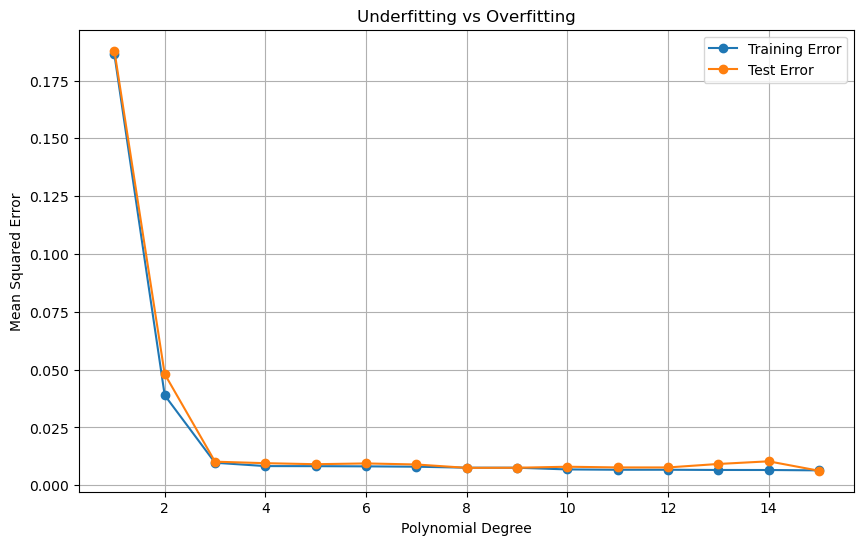

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Create toy dataset

np.random.seed(42)

X = np.sort(np.random.rand(50))

y = np.cos(1.5 * np.pi * X) + np.random.randn(50) * 0.1

# 2. Split into train and test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Test different model degrees

degrees = range(1, 16)

train_errors = []
test_errors = []


for degree in degrees:

    # Create polynomial regression model
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    # Train model
    model.fit(
        X_train.reshape(-1, 1),
        y_train
    )

    # Predictions
    train_pred = model.predict(
        X_train.reshape(-1, 1)
    )

    test_pred = model.predict(
        X_test.reshape(-1, 1)
    )

    # Calculate errors
    train_error = mean_squared_error(
        y_train,
        train_pred
    )

    test_error = mean_squared_error(
        y_test,
        test_pred
    )

    # Store errors
    train_errors.append(train_error)
    test_errors.append(test_error)

# Plot train vs test error

plt.figure(figsize=(10, 6))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Training Error"
)

plt.plot(
    degrees,
    test_errors,
    marker="o",
    label="Test Error"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")

plt.title("Underfitting vs Overfitting")

plt.legend()
plt.grid(True)

plt.show()